In [33]:
%matplotlib inline
import warnings; warnings.simplefilter('ignore')

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [35]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [36]:
df.isnull().values.any()

np.False_

In [37]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [71]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

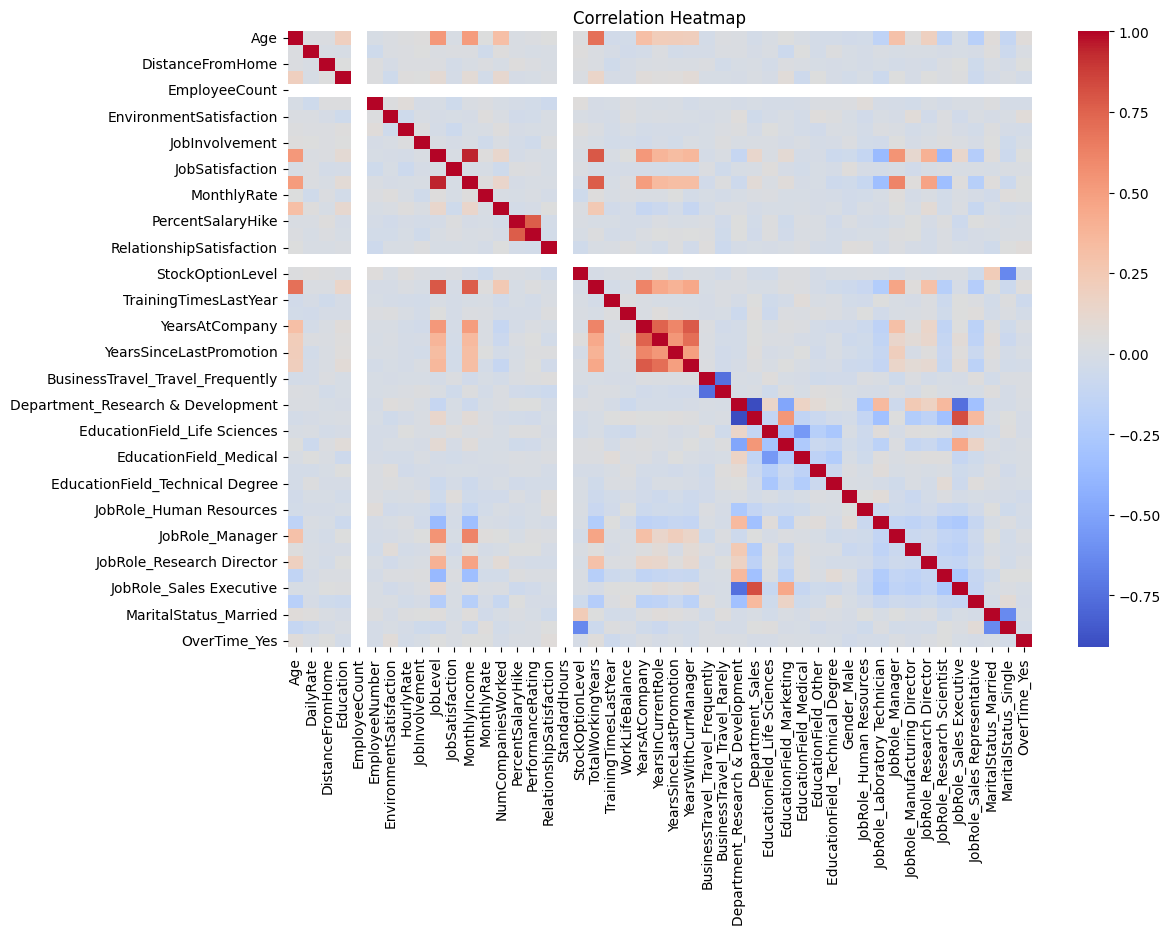

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(pd.DataFrame(X_train).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [75]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(class_weight='balanced',max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [83]:
from sklearn.svm import SVC

svm = SVC(class_weight='balanced', probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [86]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='recall')
grid_lr.fit(X_train_res, y_train_res)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

Best LR Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR Score: 0.8235348407937242


In [85]:
from sklearn.svm import SVC

svm = SVC()

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='recall')
grid_svm.fit(X_train_res, y_train_res)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM Score: 0.9898477157360407


In [87]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
print("Best DT Score:", grid_dt.best_score_)

Best DT Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best DT Score: 0.8486584926072845


In [88]:
best_lr = grid_lr.best_estimator_
best_svm = grid_svm.best_estimator_
best_dt = grid_dt.best_estimator_

In [89]:
y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_svm = best_svm.predict(X_test_scaled)
y_pred_dt = best_dt.predict(X_test)

In [90]:
#LogisticRegression

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.93      0.81      0.86       247
           1       0.40      0.66      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.81       294



In [91]:
#SVM

print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.88      0.93      0.90       247
           1       0.45      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.64       294
weighted avg       0.81      0.83      0.82       294



In [92]:
#DecisionTree

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.86      0.95      0.91       247
           1       0.45      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.66      0.58      0.60       294
weighted avg       0.80      0.83      0.81       294



In [93]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["LR", "SVM", "DT"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt)
    ]
})

print(results)

  Model  Accuracy    Recall        F1
0    LR  0.785714  0.659574  0.496000
1   SVM  0.829932  0.319149  0.375000
2    DT  0.833333  0.212766  0.289855


In [94]:
best_model_name = results.iloc[0]['Model']

if best_model_name == "LR":
    best_model = lr
    y_pred_best = y_pred_lr
elif best_model_name == "SVM":
    best_model = svm
    y_pred_best = y_pred_svm
else:
    best_model = dt
    y_pred_best = y_pred_dt

print("Best Model:", best_model_name)

Best Model: LR


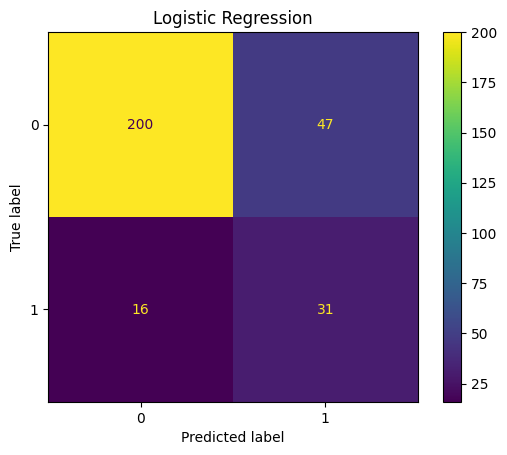

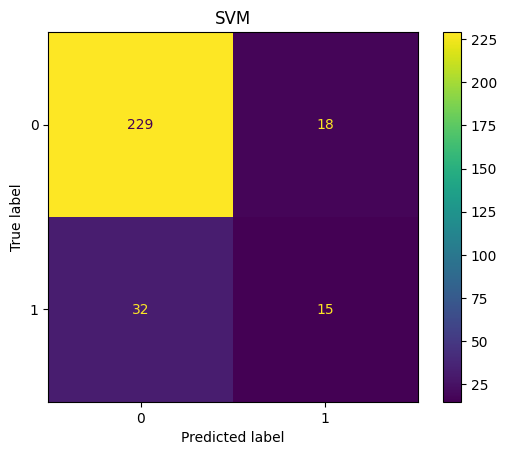

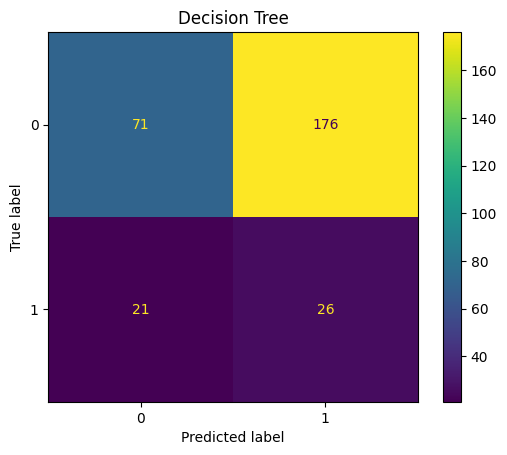

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "Decision Tree": best_dt
}

for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(name)
    plt.show()

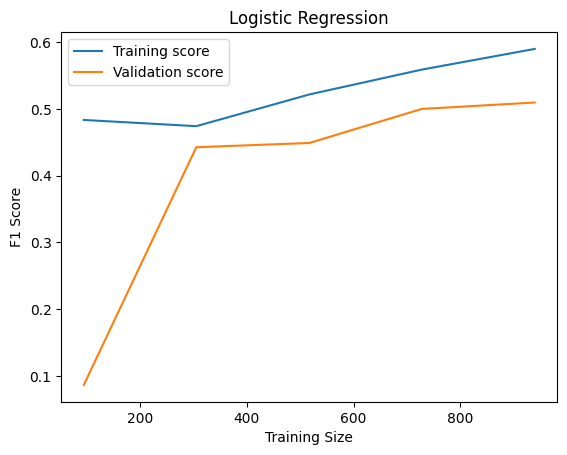

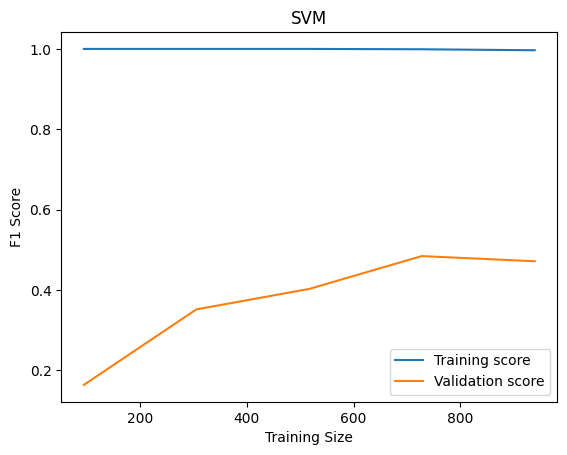

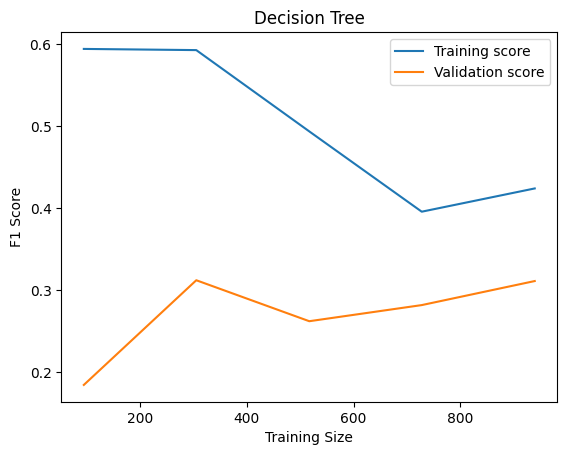

In [96]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(model, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, label="Training score")
    plt.plot(train_sizes, test_mean, label="Validation score")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.show()


for name, model in models.items():
    plot_learning_curve(model, name)